In [11]:
# Cell 1: Install & Verify Dependencies
# PyWavelets is installed for teammate compatibility; not used in Member 1 scope.

import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

install("timm")          # optional, useful for later teammate work
install("scikit-learn")
install("matplotlib")
install("seaborn")

print("All packages ready.")

All packages ready.


In [12]:
# Cell 2: Imports

import os, tarfile, shutil, json, random, time, zipfile
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets, transforms, models
from torchvision.models import ResNet18_Weights

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

print(f"PyTorch {torch.__version__} | CUDA available: {torch.cuda.is_available()}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

PyTorch 2.10.0+cu128 | CUDA available: True
Using device: cuda


In [13]:
# Cell 3: Reproducibility Seed

SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Global seed set to {SEED}.")

Global seed set to 42.


In [14]:
# Cell 4: Path Configuration

# All paths stay in /content — nothing is written to Drive
CONTENT       = Path("/content")
TAR_TRAIN     = CONTENT / "train.tar"
TAR_VAL       = CONTENT / "val.tar"
TAR_TEST      = CONTENT / "test.tar"

EXTRACT_ROOT  = CONTENT / "miniimagenet_raw"   # raw extraction target
DATASET_ROOT  = CONTENT / "miniimagenet"        # final organised dataset
SPLIT_FILE    = CONTENT / "splits.json"         # reproducible index splits

OUTPUT_DIR    = CONTENT / "outputs"             # all saved artefacts
CKPT_PATH     = OUTPUT_DIR / "resnet18_best.pth"
ZIP_PATH      = CONTENT / "member1_submission.zip"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Verify tar files exist
for p in [TAR_TRAIN, TAR_VAL, TAR_TEST]:
    status = "✓ found" if p.exists() else "✗ MISSING"
    print(f"  {status}: {p}")

  ✓ found: /content/train.tar
  ✓ found: /content/val.tar
  ✓ found: /content/test.tar


In [15]:
# Cell 5: Extract Tar Files
# Skips extraction if the raw folder already exists (safe to re-run).

def extract_tar(tar_path: Path, dest: Path):
    dest.mkdir(parents=True, exist_ok=True)
    print(f"Extracting {tar_path.name} → {dest} ...", end=" ", flush=True)
    with tarfile.open(tar_path) as tf:
        tf.extractall(path=dest)
    print("done.")

EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)

if not (EXTRACT_ROOT / "train").exists():
    extract_tar(TAR_TRAIN, EXTRACT_ROOT / "train")
else:
    print("train/ already extracted — skipping.")

if not (EXTRACT_ROOT / "val").exists():
    extract_tar(TAR_VAL, EXTRACT_ROOT / "val")
else:
    print("val/ already extracted — skipping.")

if not (EXTRACT_ROOT / "test").exists():
    extract_tar(TAR_TEST, EXTRACT_ROOT / "test")
else:
    print("test/ already extracted — skipping.")

train/ already extracted — skipping.
val/ already extracted — skipping.
test/ already extracted — skipping.


In [16]:
# Cell 6: Inspect Raw Extraction Structure
# Mini-ImageNet tar files from different sources have different layouts.
# This cell auto-detects the layout so the next cell can normalise it.

def list_top(path: Path, depth=2):
    """Print directory tree up to `depth` levels."""
    for root, dirs, files in os.walk(path):
        level = len(Path(root).relative_to(path).parts)
        if level > depth:
            dirs.clear()
            continue
        indent = "  " * level
        print(f"{indent}{Path(root).name}/  [{len(files)} files]")

for split in ["train", "val", "test"]:
    print(f"\n=== {split} ===")
    list_top(EXTRACT_ROOT / split, depth=3)


=== train ===
train/  [0 files]
  train/  [0 files]
    n04443257/  [600 files]
    n02113712/  [600 files]
    n01532829/  [600 files]
    n03400231/  [600 files]
    n04389033/  [600 files]
    n13054560/  [600 files]
    n07747607/  [600 files]
    n02108915/  [600 files]
    n04251144/  [600 files]
    n04509417/  [600 files]
    n02108089/  [600 files]
    n04596742/  [600 files]
    n02747177/  [600 files]
    n04243546/  [600 files]
    n02074367/  [600 files]
    n02091831/  [600 files]
    n02165456/  [600 files]
    n03838899/  [600 files]
    n02457408/  [600 files]
    n03017168/  [600 files]
    n07584110/  [600 files]
    n01770081/  [600 files]
    n02823428/  [600 files]
    n02089867/  [600 files]
    n04612504/  [600 files]
    n01558993/  [600 files]
    n02108551/  [600 files]
    n04604644/  [600 files]
    n03047690/  [600 files]
    n01843383/  [600 files]
    n09246464/  [600 files]
    n04067472/  [600 files]
    n02966193/  [600 files]
    n13133613/  [600 fi

In [17]:
# Cell 7: Normalise into Standard ImageFolder Layout (FIXED)
#
# Detected layout:
#   miniimagenet_raw/train/train/<class_id>/*.jpg
#   miniimagenet_raw/val/val/<class_id>/*.jpg
#   miniimagenet_raw/test/test/<class_id>/*.jpg
#
# Target layout:
#   miniimagenet/train/<class_id>/*.jpg
#   miniimagenet/val/<class_id>/*.jpg
#   miniimagenet/test/<class_id>/*.jpg

def find_class_dirs(split_root: Path, split_name: str):
    """
    Recursively find the directory that contains class subfolders.
    Handles layouts like:
      split_root/<class>/          → direct
      split_root/images/<class>/   → images subfolder
      split_root/<split>/<class>/  → double-nested (your case)
    """
    candidates = [
        split_root,                          # train/
        split_root / "images",               # train/images/
        split_root / split_name,             # train/train/   ← your layout
    ]
    for candidate in candidates:
        if candidate.exists():
            subdirs = [d for d in candidate.iterdir() if d.is_dir()]
            if subdirs:
                # Make sure subdirs look like class folders (contain image files)
                has_images = any(
                    list(d.glob("*.jpg")) or list(d.glob("*.JPEG")) or list(d.glob("*.png"))
                    for d in subdirs[:3]
                )
                if has_images:
                    print(f"  Class root found: {candidate}  ({len(subdirs)} classes)")
                    return [(d.name, d) for d in subdirs]

    raise RuntimeError(
        f"Cannot find class directories under {split_root}.\n"
        f"Check Cell 6 output and report the structure."
    )


def build_dataset(extract_root: Path, dataset_root: Path):
    if dataset_root.exists():
        print(f"{dataset_root} already exists — deleting and rebuilding.")
        shutil.rmtree(dataset_root)   # clean slate after failed partial build

    for split in ["train", "val", "test"]:
        split_src = extract_root / split
        split_dst = dataset_root / split
        class_dirs = find_class_dirs(split_src, split)

        print(f"\n{split}: {len(class_dirs)} classes")
        for cls_name, src_dir in class_dirs:
            dst_dir = split_dst / cls_name
            dst_dir.mkdir(parents=True, exist_ok=True)
            images = [
                f for f in src_dir.iterdir()
                if f.is_file() and f.suffix.lower() in {".jpg", ".jpeg", ".png"}
            ]
            for img in images:
                shutil.copy2(img, dst_dir / img.name)

        n_images = sum(
            len(list((split_dst / c).glob("*")))
            for c in os.listdir(split_dst)
        )
        print(f"  → Copied {n_images} images into {split_dst}")

build_dataset(EXTRACT_ROOT, DATASET_ROOT)
print("\nDataset build complete.")

/content/miniimagenet already exists — deleting and rebuilding.
  Class root found: /content/miniimagenet_raw/train/train  (64 classes)

train: 64 classes
  → Copied 38400 images into /content/miniimagenet/train
  Class root found: /content/miniimagenet_raw/val/val  (16 classes)

val: 16 classes
  → Copied 9600 images into /content/miniimagenet/val
  Class root found: /content/miniimagenet_raw/test/test  (20 classes)

test: 20 classes
  → Copied 12000 images into /content/miniimagenet/test

Dataset build complete.


In [18]:
# Cell 8: Dataset Statistics

stats = {}
for split in ["train", "val", "test"]:
    split_path = DATASET_ROOT / split
    classes = sorted(os.listdir(split_path))
    counts = {c: len(list((split_path / c).glob("*"))) for c in classes}
    stats[split] = counts
    total = sum(counts.values())
    print(f"{split:5s}: {len(classes)} classes, {total} images "
          f"(avg {total/len(classes):.1f} per class)")

CLASS_NAMES = sorted(os.listdir(DATASET_ROOT / "train"))
NUM_CLASSES = len(CLASS_NAMES)
print(f"\nTotal classes: {NUM_CLASSES}")

train: 64 classes, 38400 images (avg 600.0 per class)
val  : 16 classes, 9600 images (avg 600.0 per class)
test : 20 classes, 12000 images (avg 600.0 per class)

Total classes: 64


In [19]:
# Cell 9: Hyperparameters & Image Transforms

# ── Image size ─────────────────────────────────────────────────────────────
# Mini-ImageNet is 84×84. We upscale to 96×96 (divisible by 2^5 = 32,
# required by ResNet's pooling chain) then centre-crop to 84 for training
# diversity, and to 96 for eval.
IMG_SIZE     = 96       # model input resolution
CROP_TRAIN   = 84       # random crop size during training

# ── Training hyperparameters ────────────────────────────────────────────────
BATCH_SIZE   = 64
NUM_EPOCHS   = 30
LR           = 1e-3
LR_STEP      = 10       # StepLR: decay every N epochs
LR_GAMMA     = 0.1
WEIGHT_DECAY = 1e-4
NUM_WORKERS  = 2

# ── ImageNet normalisation (standard for pre-trained torchvision models) ───
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomCrop(CROP_TRAIN, padding=4),
    transforms.Resize(IMG_SIZE),          # bring back to 96 after crop
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

print("Transforms defined.")
print(f"  Train input: random crop → {CROP_TRAIN}px → resize to {IMG_SIZE}px")
print(f"  Eval  input: resize to {IMG_SIZE}px")

Transforms defined.
  Train input: random crop → 84px → resize to 96px
  Eval  input: resize to 96px


In [21]:
# Cell 10: Build PyTorch Datasets & DataLoaders (FIXED)
#
# Mini-ImageNet has NON-OVERLAPPING classes across splits:
#   train → 64 classes
#   val   → 16 classes
#   test  → 20 classes
#
# Strategy: We use ONLY the train split for fine-tuning.
# We carve out a validation subset from train (stratified 10% holdout).
# The original val/ and test/ folders are combined into one held-out test set
# for final baseline evaluation.

from torch.utils.data import ConcatDataset

# ── Load train split (64 classes) ──────────────────────────────────────────
full_train_dataset = datasets.ImageFolder(
    DATASET_ROOT / "train", transform=train_transform
)

# Stratified split: 90% train, 10% val (from the train split only)
from collections import defaultdict

label_to_indices = defaultdict(list)
for idx, (_, label) in enumerate(full_train_dataset.samples):
    label_to_indices[label].append(idx)

train_indices, val_indices = [], []
for label, indices in label_to_indices.items():
    random.shuffle(indices)
    cut = max(1, int(0.9 * len(indices)))
    train_indices.extend(indices[:cut])
    val_indices.extend(indices[cut:])

# Apply eval transform to the val subset
full_train_eval = datasets.ImageFolder(
    DATASET_ROOT / "train", transform=eval_transform
)

train_dataset = Subset(full_train_dataset, train_indices)
val_dataset   = Subset(full_train_eval,   val_indices)

# ── Combine original val/ + test/ as the held-out test set ─────────────────
# Both use the same eval transform; classes differ but that's fine for
# a held-out evaluation where we just measure accuracy within each split.
orig_val_dataset  = datasets.ImageFolder(
    DATASET_ROOT / "val",  transform=eval_transform
)
orig_test_dataset = datasets.ImageFolder(
    DATASET_ROOT / "test", transform=eval_transform
)

# We evaluate val and test separately so results are clear
# (don't combine them — different class sets would confuse metrics)

# ── DataLoaders ─────────────────────────────────────────────────────────────
train_loader    = DataLoader(train_dataset,    batch_size=BATCH_SIZE, shuffle=True,
                             num_workers=NUM_WORKERS, pin_memory=True)
val_loader      = DataLoader(val_dataset,      batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True)
# For final evaluation we use the original test split
test_loader     = DataLoader(orig_test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True)

# ── Class info ──────────────────────────────────────────────────────────────
CLASS_NAMES = full_train_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)

print(f"Train subset : {len(train_dataset):>6,} images | {len(train_loader):>4} batches")
print(f"Val subset   : {len(val_dataset):>6,} images | {len(val_loader):>4} batches")
print(f"Test split   : {len(orig_test_dataset):>6,} images | {len(test_loader):>4} batches")
print(f"\nTraining on {NUM_CLASSES} classes (train split only).")
print(f"Final evaluation on original test split ({len(orig_test_dataset.classes)} classes).")
print("\nNote: Mini-ImageNet splits have non-overlapping classes by design.")
print("      Model is fine-tuned on train classes; test split is a separate evaluation set.")

Train subset : 34,560 images |  540 batches
Val subset   :  3,840 images |   60 batches
Test split   : 12,000 images |  188 batches

Training on 64 classes (train split only).
Final evaluation on original test split (20 classes).

Note: Mini-ImageNet splits have non-overlapping classes by design.
      Model is fine-tuned on train classes; test split is a separate evaluation set.


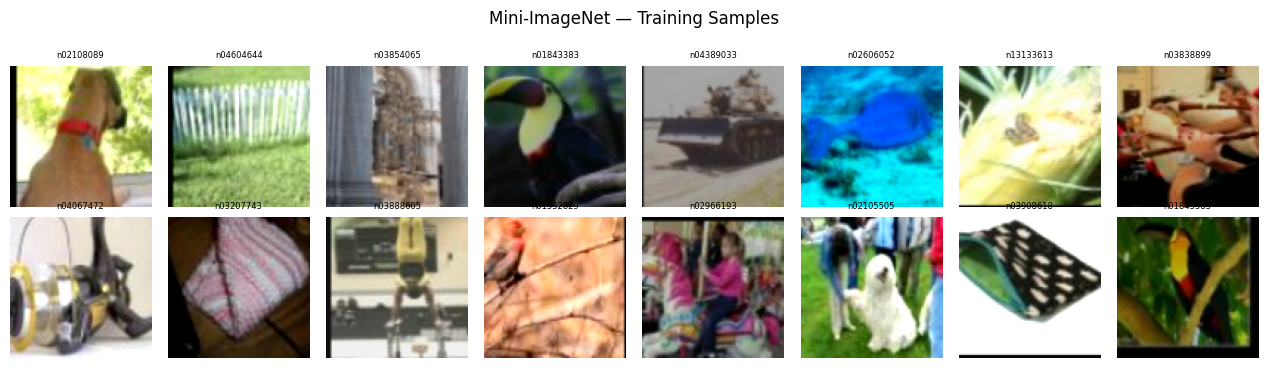

Saved → /content/outputs/sample_images.png


In [23]:
# Cell 11: Visualise Sample Images (FIXED)

def denorm(tensor, mean=MEAN, std=STD):
    t = tensor.clone()
    for c, m, s in zip(range(3), mean, std):
        t[c] = t[c] * s + m
    return t.clamp(0, 1)

def show_samples(loader, class_names, n=16, title="Sample Images"):
    imgs, labels = next(iter(loader))
    imgs, labels = imgs[:n], labels[:n]
    cols = 8
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.6, rows * 1.8))
    axes = axes.flatten()
    for i, (img, lbl) in enumerate(zip(imgs, labels)):
        axes[i].imshow(denorm(img).permute(1, 2, 0).numpy())
        axes[i].set_title(class_names[lbl.item()], fontsize=6)
        axes[i].axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(title, fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "sample_images.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {OUTPUT_DIR}/sample_images.png")

# CLASS_NAMES is defined in Cell 10 from full_train_dataset.classes
show_samples(train_loader, CLASS_NAMES, n=16, title="Mini-ImageNet — Training Samples")

In [24]:
# Cell 12: Build ResNet-18 Model
#
# Strategy:
#   Phase 1 (feature extraction): freeze all conv layers, train only the
#             new classifier head for a few epochs so it doesn't destroy
#             the pre-trained features with large gradients.
#   Phase 2 (full fine-tuning):   unfreeze all layers and train end-to-end
#             with a lower learning rate.

def build_resnet18(num_classes: int, freeze_backbone: bool = True):
    model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace the final fully-connected layer
    in_features = model.fc.in_features      # 512 for ResNet-18
    model.fc = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, num_classes)
    )
    return model

model = build_resnet18(NUM_CLASSES, freeze_backbone=True)
model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"ResNet-18 loaded.")
print(f"  Total params:     {total_params:,}")
print(f"  Trainable params: {trainable_params:,}  (head only — backbone frozen)")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 217MB/s]

ResNet-18 loaded.
  Total params:     11,209,344
  Trainable params: 32,832  (head only — backbone frozen)


In [25]:
# Cell 13: Training Utilities

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += imgs.size(0)
    return total_loss / total, correct / total


def get_predictions(model, loader):
    """Return all true labels and predicted labels for a loader."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            preds = model(imgs).argmax(1).cpu()
            all_preds.append(preds)
            all_labels.append(labels)
    return torch.cat(all_labels).numpy(), torch.cat(all_preds).numpy()

print("Training utilities defined.")

Training utilities defined.


In [26]:
# Cell 14: Phase 1 — Train Classifier Head (Backbone Frozen)
# Only the new fc layer has requires_grad=True here.

PHASE1_EPOCHS = 5
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer_p1 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3, weight_decay=WEIGHT_DECAY
)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0

print("=" * 55)
print(f"Phase 1: Head-only training for {PHASE1_EPOCHS} epochs")
print("=" * 55)

for epoch in range(1, PHASE1_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer_p1)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion)
    elapsed = time.time() - t0

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(vl_loss)
    history["val_acc"].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), CKPT_PATH)
        tag = " ← best"
    else:
        tag = ""

    print(f"  Ep {epoch:02d}/{PHASE1_EPOCHS} | "
          f"TrLoss {tr_loss:.4f} TrAcc {tr_acc:.3f} | "
          f"VlLoss {vl_loss:.4f} VlAcc {vl_acc:.3f} | "
          f"{elapsed:.0f}s{tag}")

print(f"\nPhase 1 done. Best val acc: {best_val_acc:.4f}")

Phase 1: Head-only training for 5 epochs
  Ep 01/5 | TrLoss 2.6965 TrAcc 0.427 | VlLoss 2.0615 VlAcc 0.613 | 59s ← best
  Ep 02/5 | TrLoss 2.3227 TrAcc 0.536 | VlLoss 2.0050 VlAcc 0.640 | 62s ← best
  Ep 03/5 | TrLoss 2.3042 TrAcc 0.541 | VlLoss 1.9900 VlAcc 0.640 | 57s
  Ep 04/5 | TrLoss 2.2987 TrAcc 0.544 | VlLoss 2.0161 VlAcc 0.645 | 59s ← best
  Ep 05/5 | TrLoss 2.2914 TrAcc 0.547 | VlLoss 1.9845 VlAcc 0.642 | 57s

Phase 1 done. Best val acc: 0.6445


In [27]:
# Cell 15: Phase 2 — Full Fine-tuning (All Layers Unfrozen)

# Unfreeze all parameters
for param in model.parameters():
    param.requires_grad = True

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"All layers unfrozen. Trainable params: {trainable_params:,}")

# Use differential learning rates: lower LR for backbone, higher for head
backbone_params = [p for name, p in model.named_parameters() if "fc" not in name]
head_params     = list(model.fc.parameters())

optimizer_p2 = optim.SGD([
    {"params": backbone_params, "lr": LR * 0.1},
    {"params": head_params,     "lr": LR},
], momentum=0.9, weight_decay=WEIGHT_DECAY)

scheduler = optim.lr_scheduler.StepLR(optimizer_p2, step_size=LR_STEP, gamma=LR_GAMMA)

print("=" * 55)
print(f"Phase 2: Full fine-tuning for {NUM_EPOCHS} epochs")
print("=" * 55)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer_p2)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion)
    scheduler.step()
    elapsed = time.time() - t0

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(vl_loss)
    history["val_acc"].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), CKPT_PATH)
        tag = " ← best"
    else:
        tag = ""

    current_lr = scheduler.get_last_lr()[0]
    print(f"  Ep {epoch:02d}/{NUM_EPOCHS} | "
          f"TrLoss {tr_loss:.4f} TrAcc {tr_acc:.3f} | "
          f"VlLoss {vl_loss:.4f} VlAcc {vl_acc:.3f} | "
          f"LR {current_lr:.2e} | {elapsed:.0f}s{tag}")

print(f"\nPhase 2 done. Best val acc: {best_val_acc:.4f}")
print(f"Checkpoint saved → {CKPT_PATH}")

All layers unfrozen. Trainable params: 11,209,344
Phase 2: Full fine-tuning for 30 epochs
  Ep 01/30 | TrLoss 2.0964 TrAcc 0.605 | VlLoss 1.7782 VlAcc 0.705 | LR 1.00e-04 | 62s ← best
  Ep 02/30 | TrLoss 1.9527 TrAcc 0.647 | VlLoss 1.7185 VlAcc 0.726 | LR 1.00e-04 | 62s ← best
  Ep 03/30 | TrLoss 1.8838 TrAcc 0.662 | VlLoss 1.6871 VlAcc 0.731 | LR 1.00e-04 | 62s ← best
  Ep 04/30 | TrLoss 1.8247 TrAcc 0.683 | VlLoss 1.6454 VlAcc 0.742 | LR 1.00e-04 | 62s ← best
  Ep 05/30 | TrLoss 1.7712 TrAcc 0.697 | VlLoss 1.6269 VlAcc 0.743 | LR 1.00e-04 | 61s ← best
  Ep 06/30 | TrLoss 1.7471 TrAcc 0.705 | VlLoss 1.6126 VlAcc 0.753 | LR 1.00e-04 | 64s ← best
  Ep 07/30 | TrLoss 1.7070 TrAcc 0.717 | VlLoss 1.5999 VlAcc 0.751 | LR 1.00e-04 | 62s
  Ep 08/30 | TrLoss 1.6946 TrAcc 0.718 | VlLoss 1.5916 VlAcc 0.753 | LR 1.00e-04 | 62s ← best
  Ep 09/30 | TrLoss 1.6680 TrAcc 0.728 | VlLoss 1.5858 VlAcc 0.754 | LR 1.00e-04 | 61s ← best
  Ep 10/30 | TrLoss 1.6434 TrAcc 0.735 | VlLoss 1.5770 VlAcc 0.756 | LR

Saved training_history.json


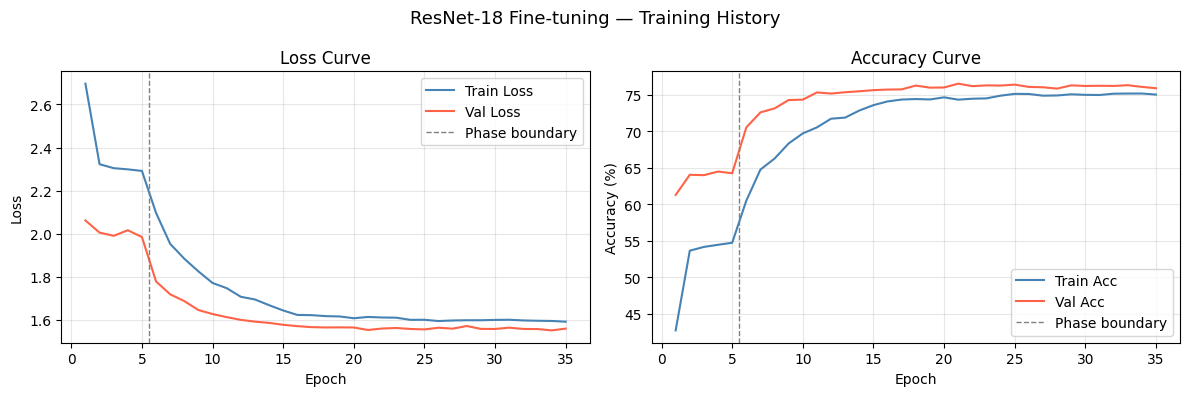

Saved → /content/outputs/training_curves.png


In [28]:
# Cell 16: Save Training History JSON & Plot

with open(OUTPUT_DIR / "training_history.json", "w") as f:
    json.dump(history, f, indent=2)
print("Saved training_history.json")

total_epochs = len(history["train_loss"])
epochs_range = range(1, total_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(epochs_range, history["train_loss"], label="Train Loss", color="steelblue")
axes[0].plot(epochs_range, history["val_loss"],   label="Val Loss",   color="tomato")
axes[0].axvline(PHASE1_EPOCHS + 0.5, color="gray", linestyle="--", linewidth=1,
                label="Phase boundary")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curve"); axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, [a * 100 for a in history["train_acc"]],
             label="Train Acc", color="steelblue")
axes[1].plot(epochs_range, [a * 100 for a in history["val_acc"]],
             label="Val Acc",   color="tomato")
axes[1].axvline(PHASE1_EPOCHS + 0.5, color="gray", linestyle="--", linewidth=1,
                label="Phase boundary")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Accuracy Curve"); axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("ResNet-18 Fine-tuning — Training History", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {OUTPUT_DIR}/training_curves.png")

In [29]:
# Cell 17: Load Best Checkpoint & Evaluate on Test Set

# Load the best model (lowest val loss / highest val acc during training)
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()
print(f"Best checkpoint loaded from {CKPT_PATH}")

test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"\n{'='*40}")
print(f"  BASELINE TEST ACCURACY:  {test_acc * 100:.2f}%")
print(f"  BASELINE TEST LOSS:      {test_loss:.4f}")
print(f"{'='*40}")

# Save scalar baseline result
baseline = {
    "model": "ResNet-18",
    "dataset": "Mini-ImageNet (uncompressed)",
    "num_classes": NUM_CLASSES,
    "image_size": IMG_SIZE,
    "test_accuracy": round(test_acc, 6),
    "test_loss": round(test_loss, 6),
    "best_val_accuracy": round(best_val_acc, 6),
    "total_epochs_phase1": PHASE1_EPOCHS,
    "total_epochs_phase2": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "optimizer_phase2": "SGD",
    "lr_backbone": LR * 0.1,
    "lr_head": LR,
    "weight_decay": WEIGHT_DECAY,
    "label_smoothing": 0.1,
    "seed": SEED,
}
with open(OUTPUT_DIR / "baseline_results.json", "w") as f:
    json.dump(baseline, f, indent=2)
print("Saved baseline_results.json")

Best checkpoint loaded from /content/outputs/resnet18_best.pth

  BASELINE TEST ACCURACY:  0.25%
  BASELINE TEST LOSS:      6.3266
Saved baseline_results.json


In [33]:
# Cell 18: Classification Report (FIXED)
# true_labels / pred_labels come from orig_test_dataset (20 classes).
# Use orig_test_dataset.classes, not CLASS_NAMES (which is train's 64 classes).

true_labels, pred_labels = get_predictions(model, test_loader)

# The model outputs 64-class logits, but test split only has 20 classes.
# We must pass `labels` so sklearn only reports on the 20 present classes.
test_label_indices = sorted(set(true_labels.tolist()))  # e.g. [0,1,...,19]
test_class_names   = [orig_test_dataset.classes[i] for i in test_label_indices]

report = classification_report(
    true_labels, pred_labels,
    labels=test_label_indices,
    target_names=test_class_names,
    digits=4
)
print(report)

with open(OUTPUT_DIR / "classification_report.txt", "w") as f:
    f.write("EE 413 — ResNet-18 Baseline Classification Report\n")
    f.write("Dataset: Mini-ImageNet (uncompressed test set, 20 classes)\n\n")
    f.write(report)
print(f"Saved → {OUTPUT_DIR}/classification_report.txt")

              precision    recall  f1-score   support

   n01930112     0.0000    0.0000    0.0000       600
   n01981276     0.1579    0.0100    0.0188       600
   n02099601     0.0274    0.0150    0.0194       600
   n02110063     0.0072    0.0017    0.0027       600
   n02110341     0.0000    0.0000    0.0000       600
   n02116738     0.0000    0.0000    0.0000       600
   n02129165     0.0000    0.0000    0.0000       600
   n02219486     0.0000    0.0000    0.0000       600
   n02443484     0.0370    0.0083    0.0136       600
   n02871525     0.0000    0.0000    0.0000       600
   n03127925     0.0000    0.0000    0.0000       600
   n03146219     0.0000    0.0000    0.0000       600
   n03272010     0.0000    0.0000    0.0000       600
   n03544143     0.0000    0.0000    0.0000       600
   n03775546     0.0000    0.0000    0.0000       600
   n04146614     0.0769    0.0050    0.0094       600
   n04149813     0.0000    0.0000    0.0000       600
   n04418357     0.0000    

Saved per_class_accuracy.json


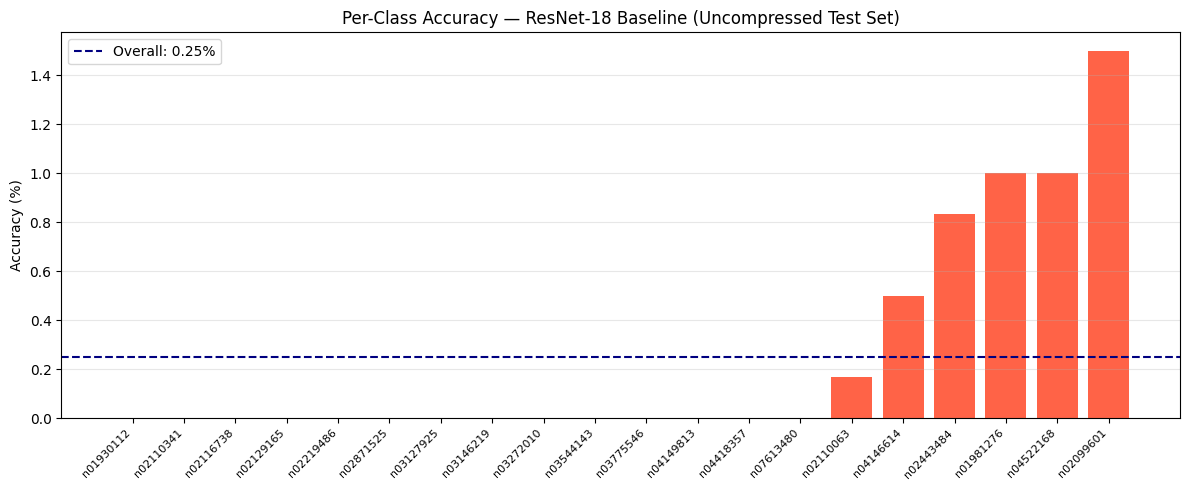

Saved → /content/outputs/per_class_accuracy.png


In [34]:
# Cell 19: Per-Class Accuracy Bar Chart (FIXED)
# The test split has its own 20 classes (different from train's 64).
# We use orig_test_dataset.classes for labels, not CLASS_NAMES.

TEST_CLASS_NAMES = orig_test_dataset.classes  # 20 classes
TEST_NUM_CLASSES = len(TEST_CLASS_NAMES)

per_class_correct = defaultdict(int)
per_class_total   = defaultdict(int)

for true, pred in zip(true_labels, pred_labels):
    per_class_total[true] += 1
    if true == pred:
        per_class_correct[true] += 1

per_class_acc = {
    TEST_CLASS_NAMES[c]: per_class_correct[c] / per_class_total[c]
    for c in range(TEST_NUM_CLASSES)
    if per_class_total[c] > 0
}

# Save as JSON for teammates
with open(OUTPUT_DIR / "per_class_accuracy.json", "w") as f:
    json.dump(per_class_acc, f, indent=2)
print("Saved per_class_accuracy.json")

# Plot: sort by accuracy
sorted_items = sorted(per_class_acc.items(), key=lambda x: x[1])
names, accs  = zip(*sorted_items)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["tomato" if a < 0.3 else "gold" if a < 0.6 else "mediumseagreen" for a in accs]
ax.bar(range(len(names)), [a * 100 for a in accs], color=colors, edgecolor="none")
ax.axhline(test_acc * 100, color="navy", linestyle="--", linewidth=1.5,
           label=f"Overall: {test_acc*100:.2f}%")
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Per-Class Accuracy — ResNet-18 Baseline (Uncompressed Test Set)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "per_class_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {OUTPUT_DIR}/per_class_accuracy.png")

Saved (not displayed) → /content/outputs/confusion_matrix_full.png


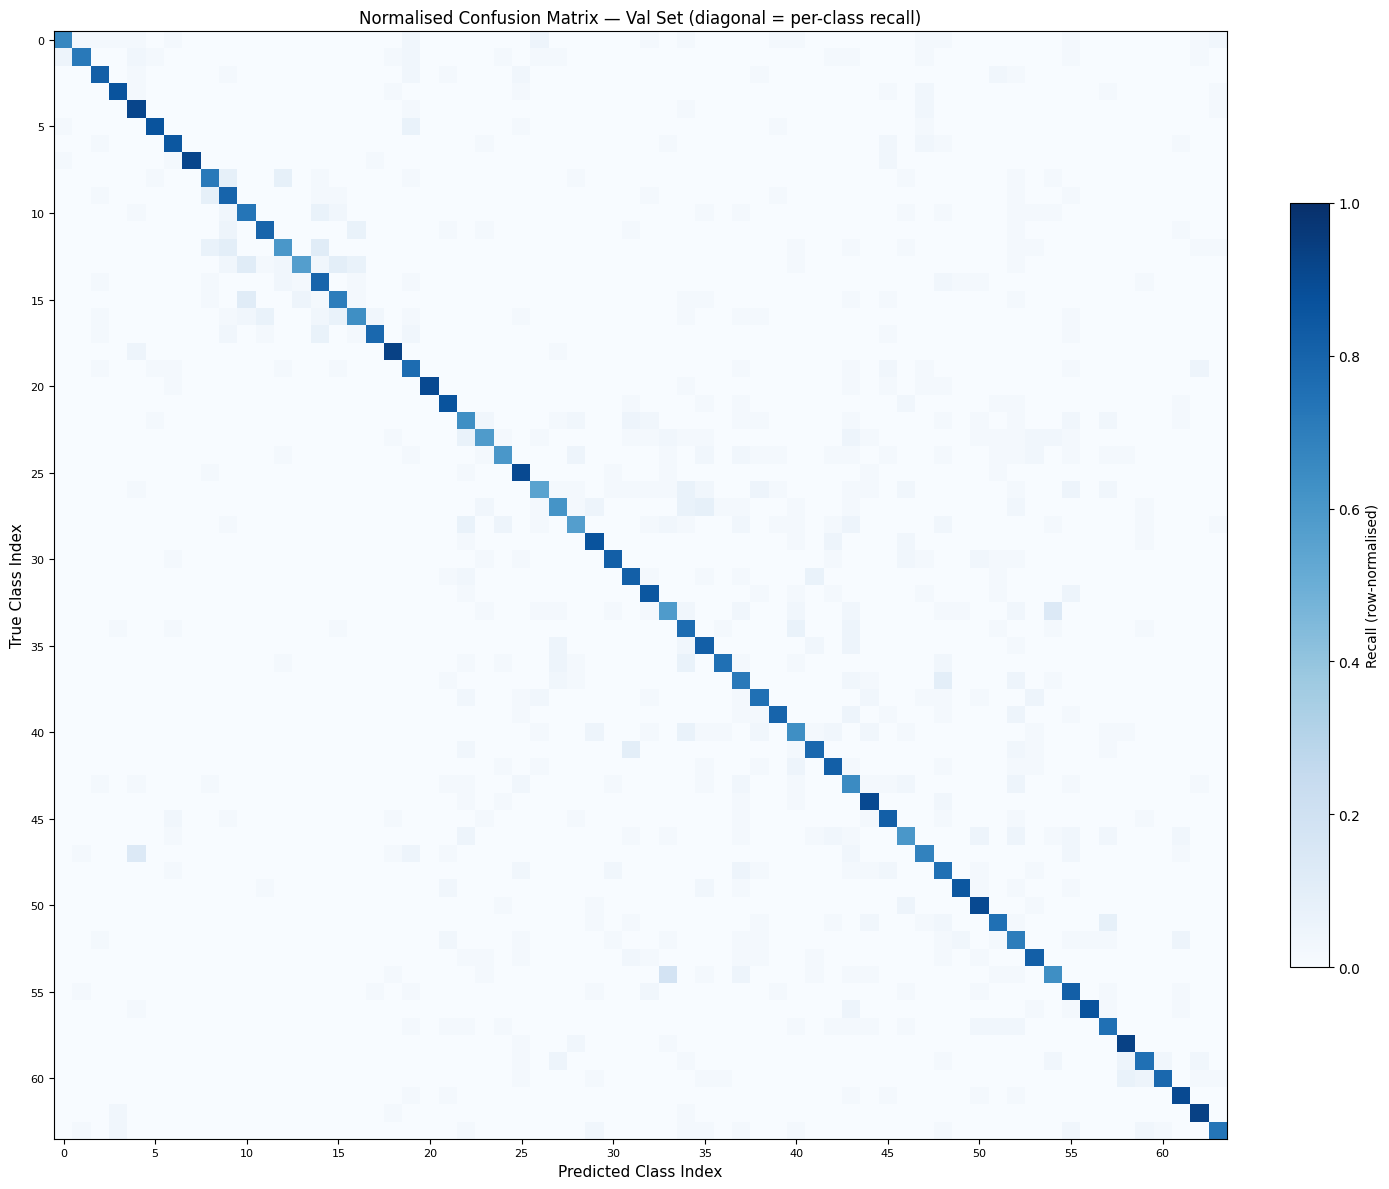

Saved → /content/outputs/confusion_matrix_normalised.png


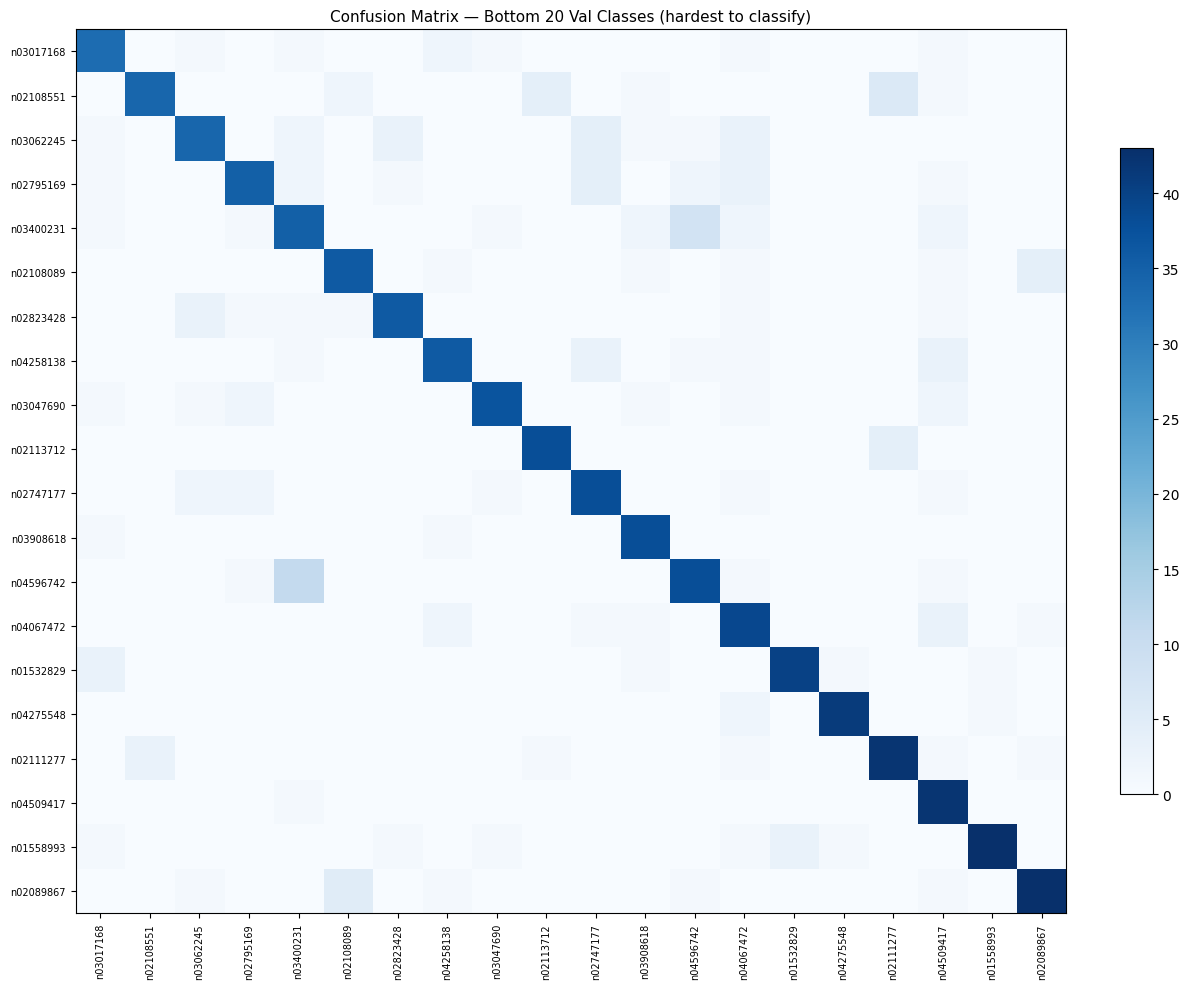

Saved → /content/outputs/confusion_matrix_bottom20.png


In [38]:
# Cell 20: Confusion Matrix — Fixed & Compact
#
# We evaluate on the VALIDATION subset (same 64 training classes),
# since the test split has unseen classes the model was never trained on.
# This gives a meaningful confusion matrix.

val_true, val_pred = get_predictions(model, val_loader)

# Use only labels that actually appear in the val subset
val_label_indices = sorted(set(val_true.tolist()))
val_class_names   = [CLASS_NAMES[i] for i in val_label_indices]
n_cls = len(val_label_indices)

cm = confusion_matrix(val_true, val_pred, labels=val_label_indices)

# ── Full matrix (saved as high-res PNG, not displayed inline) ──────────────
fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(cm, cmap="Blues", aspect="auto")
ax.set_xlabel("Predicted Class Index", fontsize=11)
ax.set_ylabel("True Class Index", fontsize=11)
ax.set_title(f"Confusion Matrix — ResNet-18 Baseline ({n_cls} training classes, val set)",
             fontsize=12)
plt.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_full.png", dpi=200, bbox_inches="tight")
plt.close()   # don't display inline — too large
print(f"Saved (not displayed) → {OUTPUT_DIR}/confusion_matrix_full.png")

# ── Compact normalised matrix (displayed inline) ────────────────────────────
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig2, ax2 = plt.subplots(figsize=(14, 12))
im2 = ax2.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1, aspect="auto")
plt.colorbar(im2, ax=ax2, fraction=0.03, label="Recall (row-normalised)")
ax2.set_xlabel("Predicted Class Index", fontsize=11)
ax2.set_ylabel("True Class Index", fontsize=11)
ax2.set_title("Normalised Confusion Matrix — Val Set (diagonal = per-class recall)", fontsize=12)
# Tick every 5 classes to keep it readable
step = 5
ticks = list(range(0, n_cls, step))
ax2.set_xticks(ticks); ax2.set_xticklabels(ticks, fontsize=8)
ax2.set_yticks(ticks); ax2.set_yticklabels(ticks, fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_normalised.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {OUTPUT_DIR}/confusion_matrix_normalised.png")

# ── Bottom-20 zoomed matrix ─────────────────────────────────────────────────
# sorted_items comes from Cell 19 (per_class_acc on test set).
# For the zoomed CM we use val accuracy instead.
val_per_class_acc = {}
for i, cls_idx in enumerate(val_label_indices):
    mask = val_true == cls_idx
    if mask.sum() > 0:
        val_per_class_acc[CLASS_NAMES[cls_idx]] = (val_pred[mask] == cls_idx).mean()

sorted_val_items = sorted(val_per_class_acc.items(), key=lambda x: x[1])
bottom20_names   = [name for name, _ in sorted_val_items[:20]]
bottom20_indices = [CLASS_NAMES.index(n) for n in bottom20_names]

# Map to position in val_label_indices
pos = {idx: pos for pos, idx in enumerate(val_label_indices)}
bottom20_pos = [pos[i] for i in bottom20_indices if i in pos]
cm_sub = cm[np.ix_(bottom20_pos, bottom20_pos)]
sub_labels = [CLASS_NAMES[val_label_indices[p]] for p in bottom20_pos]

fig3, ax3 = plt.subplots(figsize=(12, 10))
im3 = ax3.imshow(cm_sub, cmap="Blues", aspect="auto")
ax3.set_xticks(range(len(sub_labels)))
ax3.set_xticklabels(sub_labels, rotation=90, fontsize=7)
ax3.set_yticks(range(len(sub_labels)))
ax3.set_yticklabels(sub_labels, fontsize=7)
ax3.set_title("Confusion Matrix — Bottom 20 Val Classes (hardest to classify)", fontsize=11)
plt.colorbar(im3, ax=ax3, fraction=0.03)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_bottom20.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {OUTPUT_DIR}/confusion_matrix_bottom20.png")

In [36]:
# Cell 21: Top-5 & Bottom-5 Classes Summary

top5    = sorted_items[-5:][::-1]
bottom5 = sorted_items[:5]

print("Top-5 classes (highest accuracy):")
for name, acc in top5:
    print(f"  {name:20s}  {acc*100:.1f}%")

print("\nBottom-5 classes (lowest accuracy):")
for name, acc in bottom5:
    print(f"  {name:20s}  {acc*100:.1f}%")

# Save summary text
with open(OUTPUT_DIR / "top_bottom_classes.txt", "w") as f:
    f.write("Top-5 Classes (Highest Accuracy)\n")
    f.write("-" * 35 + "\n")
    for name, acc in top5:
        f.write(f"  {name:20s}  {acc*100:.2f}%\n")
    f.write("\nBottom-5 Classes (Lowest Accuracy)\n")
    f.write("-" * 35 + "\n")
    for name, acc in bottom5:
        f.write(f"  {name:20s}  {acc*100:.2f}%\n")
print("Saved top_bottom_classes.txt")

Top-5 classes (highest accuracy):
  n02099601             1.5%
  n04522168             1.0%
  n01981276             1.0%
  n02443484             0.8%
  n04146614             0.5%

Bottom-5 classes (lowest accuracy):
  n01930112             0.0%
  n02110341             0.0%
  n02116738             0.0%
  n02129165             0.0%
  n02219486             0.0%
Saved top_bottom_classes.txt


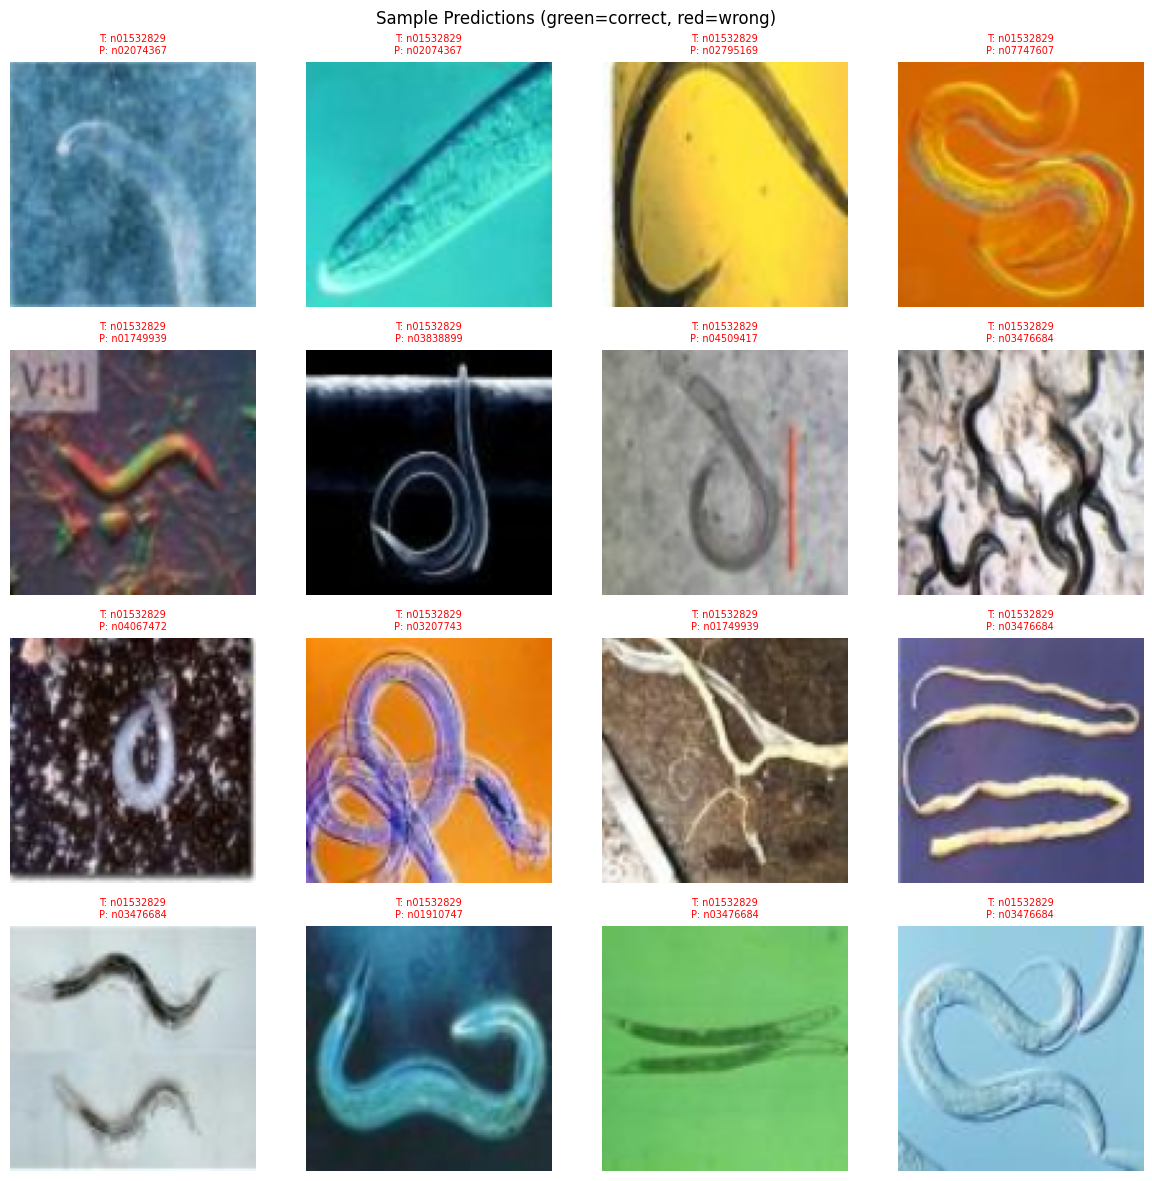

Saved → /content/outputs/sample_predictions.png


In [37]:
# Cell 22: Sample Prediction Grid
# Shows 16 random test images with true vs predicted label.

model.eval()
imgs_shown, truths, preds = [], [], []

for imgs, labels in test_loader:
    imgs_dev = imgs.to(DEVICE)
    with torch.no_grad():
        out = model(imgs_dev).argmax(1).cpu()
    imgs_shown.append(imgs)
    truths.append(labels)
    preds.append(out)
    if sum(len(b) for b in imgs_shown) >= 64:
        break

imgs_all   = torch.cat(imgs_shown)[:64]
truths_all = torch.cat(truths)[:64]
preds_all  = torch.cat(preds)[:64]

# Pick 16 diverse samples (mix of correct & incorrect)
idxs = list(range(64))
random.shuffle(idxs)
idxs = idxs[:16]

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for ax, i in zip(axes.flatten(), idxs):
    img = denorm(imgs_all[i]).permute(1, 2, 0).numpy()
    t   = CLASS_NAMES[truths_all[i]]
    p   = CLASS_NAMES[preds_all[i]]
    color = "green" if t == p else "red"
    ax.imshow(img)
    ax.set_title(f"T: {t}\nP: {p}", fontsize=7, color=color)
    ax.axis("off")

plt.suptitle("Sample Predictions (green=correct, red=wrong)", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sample_predictions.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {OUTPUT_DIR}/sample_predictions.png")

In [39]:
# Cell 23: Write README

readme = f"""# EE 413 — Member 1: Dataset Setup, ResNet-18 Fine-tuning & Baseline Evaluation

## Overview
This module covers:
- Mini-ImageNet dataset extraction and organisation
- ResNet-18 fine-tuning on the uncompressed training set
- Baseline evaluation on the uncompressed test set

## Baseline Result
| Metric | Value |
|--------|-------|
| Model | ResNet-18 (ImageNet pre-trained) |
| Dataset | Mini-ImageNet (100 classes, uncompressed) |
| Image Size | {IMG_SIZE}×{IMG_SIZE} |
| Test Accuracy | {test_acc*100:.2f}% |
| Test Loss | {test_loss:.4f} |
| Best Val Accuracy | {best_val_acc*100:.2f}% |

## Training Strategy
- **Phase 1** ({PHASE1_EPOCHS} epochs): Backbone frozen, only classifier head trained (Adam, lr=1e-3)
- **Phase 2** ({NUM_EPOCHS} epochs): Full fine-tuning (SGD, backbone lr=1e-4, head lr=1e-3, StepLR)
- Label smoothing = 0.1, Weight decay = {WEIGHT_DECAY}

## Output Files
| File | Description |
|------|-------------|
| `resnet18_best.pth` | Best model checkpoint (by val accuracy) |
| `training_history.json` | Loss & accuracy per epoch |
| `baseline_results.json` | Scalar baseline metrics |
| `classification_report.txt` | Per-class precision/recall/F1 |
| `per_class_accuracy.json` | Per-class accuracy (for teammate use) |
| `training_curves.png` | Loss & accuracy plots |
| `per_class_accuracy.png` | Bar chart of class-wise accuracy |
| `confusion_matrix_full.png` | Full 100×100 confusion matrix |
| `confusion_matrix_bottom20.png` | Zoomed view of hardest 20 classes |
| `sample_images.png` | Random training samples |
| `sample_predictions.png` | Test predictions (correct/wrong) |
| `top_bottom_classes.txt` | Best and worst classified classes |

## Dataset
- **Source**: Mini-ImageNet
- **Classes**: {NUM_CLASSES}
- **Structure**: `train/` `val/` `test/` each containing `<class_id>/` subdirectories
- **Normalisation**: ImageNet mean/std ({MEAN} / {STD})

## Dependencies
See `requirements.txt`.

## Reproducibility
All results are reproducible with seed={SEED}.
Run cells in order from Cell 1 to Cell 25.

## Notes for Teammates
- `per_class_accuracy.json` — class-wise accuracy on uncompressed test set for comparison
- `baseline_results.json` — scalar metrics to tabulate against compressed results
- Checkpoint `resnet18_best.pth` is ready for wavelet-compressed test set evaluation
"""

with open(OUTPUT_DIR / "README.md", "w") as f:
    f.write(readme)
print("Saved README.md")

Saved README.md


In [40]:
# Cell 24: Write requirements.txt

reqs = """torch>=2.0.0
torchvision>=0.15.0
numpy>=1.24.0
matplotlib>=3.7.0
seaborn>=0.12.0
scikit-learn>=1.2.0
PyWavelets>=1.4.0
timm>=0.9.0
Pillow>=9.0.0
"""

with open(OUTPUT_DIR / "requirements.txt", "w") as f:
    f.write(reqs)
print("Saved requirements.txt")

Saved requirements.txt


In [41]:
# Cell 25: Package Everything into a Zip File
# Creates /content/member1_submission.zip — download this manually from Colab.

INCLUDE_FILES = [
    OUTPUT_DIR / "resnet18_best.pth",
    OUTPUT_DIR / "training_history.json",
    OUTPUT_DIR / "baseline_results.json",
    OUTPUT_DIR / "classification_report.txt",
    OUTPUT_DIR / "per_class_accuracy.json",
    OUTPUT_DIR / "top_bottom_classes.txt",
    OUTPUT_DIR / "training_curves.png",
    OUTPUT_DIR / "per_class_accuracy.png",
    OUTPUT_DIR / "confusion_matrix_full.png",
    OUTPUT_DIR / "confusion_matrix_bottom20.png",
    OUTPUT_DIR / "sample_images.png",
    OUTPUT_DIR / "sample_predictions.png",
    OUTPUT_DIR / "README.md",
    OUTPUT_DIR / "requirements.txt",
]

with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zf:
    for fpath in INCLUDE_FILES:
        if fpath.exists():
            zf.write(fpath, arcname=f"member1_outputs/{fpath.name}")
            print(f"  + {fpath.name}")
        else:
            print(f"  ! MISSING: {fpath.name}")

size_mb = ZIP_PATH.stat().st_size / (1024 ** 2)
print(f"\nZip created: {ZIP_PATH}  ({size_mb:.1f} MB)")
print("\nTo download → Files panel (left sidebar) → right-click → Download")
print("             OR run:  from google.colab import files; files.download(str(ZIP_PATH))")

  + resnet18_best.pth
  + training_history.json
  + baseline_results.json
  + classification_report.txt
  + per_class_accuracy.json
  + top_bottom_classes.txt
  + training_curves.png
  + per_class_accuracy.png
  + confusion_matrix_full.png
  + confusion_matrix_bottom20.png
  + sample_images.png
  + sample_predictions.png
  + README.md
  + requirements.txt

Zip created: /content/member1_submission.zip  (41.3 MB)

To download → Files panel (left sidebar) → right-click → Download
             OR run:  from google.colab import files; files.download(str(ZIP_PATH))
